In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader

import torchvision
import torchvision.transforms as transforms

import matplotlib.pyplot as plt
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [2]:
# For autoencoders we only use ToTensor() (no Normalize).
# Pixel values stay in [0, 1], which matches the Sigmoid output of our decoder.
# We don't need labels at all — the input image IS the target.
transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=True, download=True, transform=transform
)
test_dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=False, download=True, transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=128, shuffle=False)

print(f"Train samples: {len(train_dataset)} | Test samples: {len(test_dataset)}")

100%|██████████| 26.4M/26.4M [00:01<00:00, 19.0MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 306kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 4.97MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 15.4MB/s]

Train samples: 60000 | Test samples: 10000


In [3]:
# An autoencoder has two parts:
#   Encoder : compresses the image into a small latent vector (bottleneck)
#   Decoder : tries to reconstruct the original image from that vector
#
# The bottleneck forces the network to learn the most important features —
# it can't just copy the input, so it must learn structure.

class Encoder(nn.Module):
    """Compresses 784 pixels → latent_dim features."""
    def __init__(self, latent_dim):
        super(Encoder, self).__init__()
        self.fc1 = nn.Linear(784, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, latent_dim)   # bottleneck layer

    def forward(self, x):
        x = x.view(x.size(0), -1)               # flatten [batch, 1, 28, 28] → [batch, 784]
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)                          # no activation on bottleneck (linear encoding)
        return x


class Decoder(nn.Module):
    """Reconstructs 784 pixels from latent_dim features."""
    def __init__(self, latent_dim):
        super(Decoder, self).__init__()
        self.fc1 = nn.Linear(latent_dim, 128)
        self.fc2 = nn.Linear(128, 256)
        self.fc3 = nn.Linear(256, 784)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = torch.sigmoid(self.fc3(x))          # sigmoid squashes output to [0, 1] to match pixel range
        x = x.view(x.size(0), 1, 28, 28)        # reshape back to image format
        return x


class Autoencoder(nn.Module):
    """Combines Encoder and Decoder into one model."""
    def __init__(self, latent_dim=32):
        super(Autoencoder, self).__init__()
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)

    def forward(self, x):
        latent      = self.encoder(x)            # compress
        reconstructed = self.decoder(latent)     # reconstruct
        return reconstructed


LATENT_DIM = 32    # number of values used to represent each image in compressed form

model     = Autoencoder(latent_dim=LATENT_DIM).to(device)
# MSELoss measures average squared difference between original and reconstructed pixels.
# Lower = better reconstruction quality.
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal trainable parameters: {total_params}")

Autoencoder(
  (encoder): Encoder(
    (fc1): Linear(in_features=784, out_features=256, bias=True)
    (fc2): Linear(in_features=256, out_features=128, bias=True)
    (fc3): Linear(in_features=128, out_features=32, bias=True)
  )
  (decoder): Decoder(
    (fc1): Linear(in_features=32, out_features=128, bias=True)
    (fc2): Linear(in_features=128, out_features=256, bias=True)
    (fc3): Linear(in_features=256, out_features=784, bias=True)
  )
)

Total trainable parameters: 476720


In [4]:
EPOCHS = 20
train_losses = []
val_losses   = []

for epoch in range(EPOCHS):

    # ── Training ──────────────────────────────────────────
    model.train()
    running_loss = 0.0

    for images, _ in train_loader:      # labels ignored — autoencoder is unsupervised
        images = images.to(device)

        optimizer.zero_grad()
        reconstructed = model(images)
        loss = criterion(reconstructed, images)   # compare output to the *input itself*
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)
    train_losses.append(train_loss)

    # ── Validation ────────────────────────────────────────
    model.eval()
    val_running_loss = 0.0

    with torch.no_grad():
        for images, _ in test_loader:
            images = images.to(device)
            reconstructed = model(images)
            loss = criterion(reconstructed, images)
            val_running_loss += loss.item()

    val_loss = val_running_loss / len(test_loader)
    val_losses.append(val_loss)

    print(f"Epoch [{epoch+1:02d}/{EPOCHS}]  |  "
          f"Train Loss: {train_loss:.5f}  |  Val Loss: {val_loss:.5f}")

Epoch [01/20]  |  Train Loss: 0.03785  |  Val Loss: 0.02211
Epoch [02/20]  |  Train Loss: 0.02023  |  Val Loss: 0.01943
Epoch [03/20]  |  Train Loss: 0.01801  |  Val Loss: 0.01721
Epoch [04/20]  |  Train Loss: 0.01648  |  Val Loss: 0.01580
Epoch [05/20]  |  Train Loss: 0.01521  |  Val Loss: 0.01473
Epoch [06/20]  |  Train Loss: 0.01421  |  Val Loss: 0.01441
Epoch [07/20]  |  Train Loss: 0.01352  |  Val Loss: 0.01337
Epoch [08/20]  |  Train Loss: 0.01295  |  Val Loss: 0.01292
Epoch [09/20]  |  Train Loss: 0.01244  |  Val Loss: 0.01262
Epoch [10/20]  |  Train Loss: 0.01200  |  Val Loss: 0.01195
Epoch [11/20]  |  Train Loss: 0.01163  |  Val Loss: 0.01163
Epoch [12/20]  |  Train Loss: 0.01128  |  Val Loss: 0.01132
Epoch [13/20]  |  Train Loss: 0.01099  |  Val Loss: 0.01117
Epoch [14/20]  |  Train Loss: 0.01074  |  Val Loss: 0.01085
Epoch [15/20]  |  Train Loss: 0.01052  |  Val Loss: 0.01069
Epoch [16/20]  |  Train Loss: 0.01033  |  Val Loss: 0.01043
Epoch [17/20]  |  Train Loss: 0.01013  |

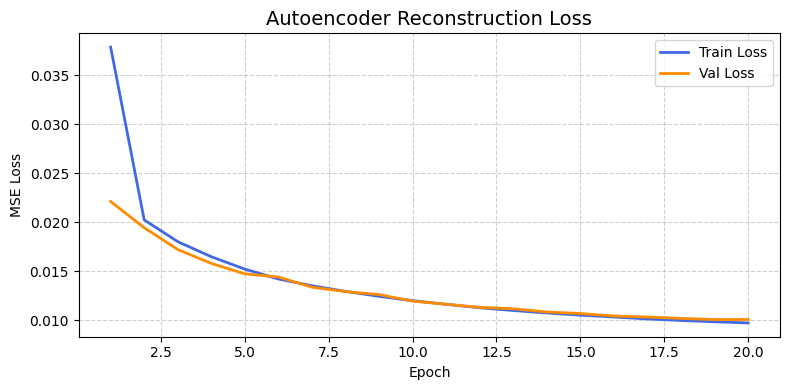

Final Train Loss: 0.00973 | Final Val Loss: 0.01008


In [5]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, EPOCHS+1), train_losses, label='Train Loss', color='royalblue', linewidth=2)
plt.plot(range(1, EPOCHS+1), val_losses,   label='Val Loss',   color='darkorange', linewidth=2)
plt.title('Autoencoder Reconstruction Loss', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('autoencoder_loss.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Final Train Loss: {train_losses[-1]:.5f} | Final Val Loss: {val_losses[-1]:.5f}")

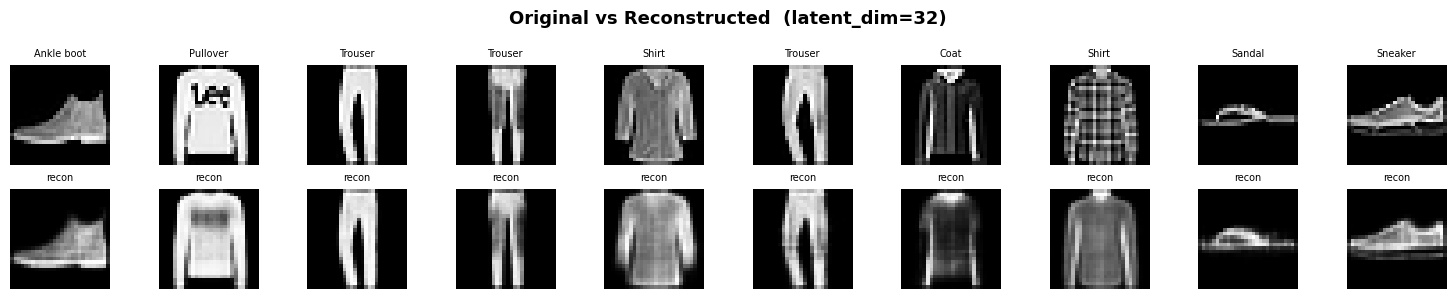

In [6]:
# Pick the first batch from the test set and compare side by side
model.eval()
test_images, test_labels = next(iter(test_loader))
test_images = test_images.to(device)

with torch.no_grad():
    reconstructed = model(test_images)

# Move to CPU for plotting
test_images   = test_images.cpu()
reconstructed = reconstructed.cpu()

# Class names for Fashion-MNIST
class_names = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

n = 10    # number of images to show
fig, axes = plt.subplots(2, n, figsize=(15, 3))

for i in range(n):
    # Top row: original images
    axes[0, i].imshow(test_images[i].squeeze(), cmap='gray')
    axes[0, i].set_title(class_names[test_labels[i]], fontsize=7)
    axes[0, i].axis('off')

    # Bottom row: reconstructed images
    axes[1, i].imshow(reconstructed[i].squeeze(), cmap='gray')
    axes[1, i].set_title('recon', fontsize=7)
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('Original',      fontsize=10)
axes[1, 0].set_ylabel('Reconstructed', fontsize=10)

plt.suptitle(f'Original vs Reconstructed  (latent_dim={LATENT_DIM})', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('reconstruction_comparison.png', dpi=150, bbox_inches='tight')
plt.show()



--- Training with latent_dim = 4 ---
  Epoch 5/10 | Loss: 0.01980
  Epoch 10/10 | Loss: 0.01869

--- Training with latent_dim = 16 ---
  Epoch 5/10 | Loss: 0.01516
  Epoch 10/10 | Loss: 0.01250

--- Training with latent_dim = 32 ---
  Epoch 5/10 | Loss: 0.01523
  Epoch 10/10 | Loss: 0.01215

--- Training with latent_dim = 64 ---
  Epoch 5/10 | Loss: 0.01463
  Epoch 10/10 | Loss: 0.01164


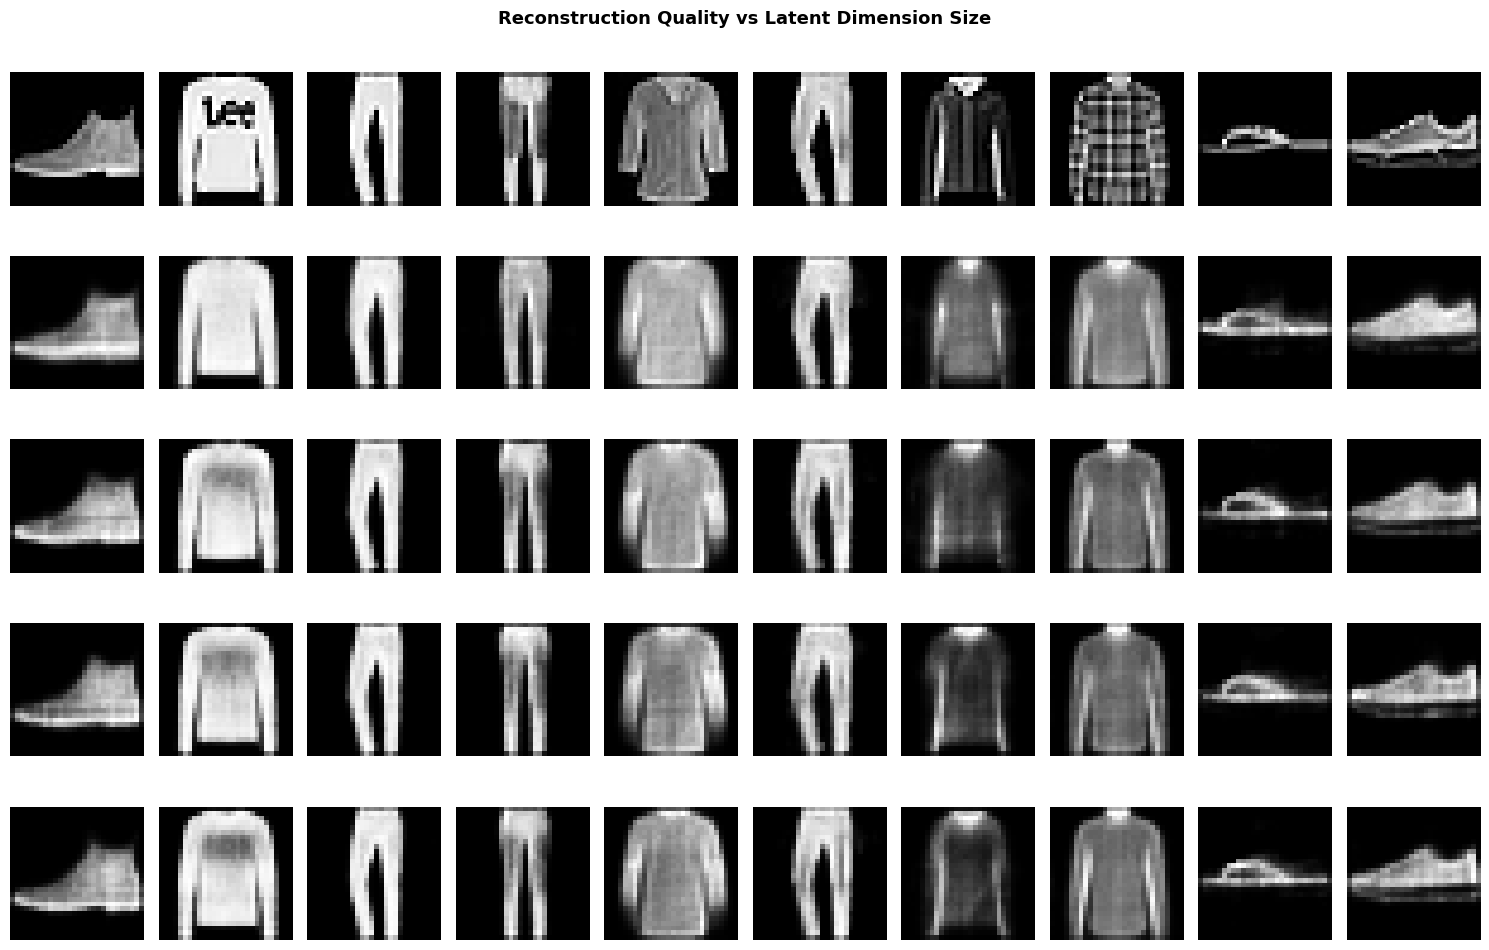

In [7]:
# This is the "bonus within the bonus" — comparing how well the autoencoder
# reconstructs images as the bottleneck gets smaller or larger.
# A tiny latent_dim forces heavy compression; quality drops but structure remains.

latent_dims  = [4, 16, 32, 64]
results      = {}    # stores {latent_dim: (train_loss, val_loss, reconstructed_images)}

for ld in latent_dims:
    print(f"\n--- Training with latent_dim = {ld} ---")

    exp_model     = Autoencoder(latent_dim=ld).to(device)
    exp_optimizer = optim.Adam(exp_model.parameters(), lr=0.001)

    # Train for fewer epochs just for comparison
    for epoch in range(10):
        exp_model.train()
        ep_loss = 0.0
        for images, _ in train_loader:
            images = images.to(device)
            exp_optimizer.zero_grad()
            out  = exp_model(images)
            loss = criterion(out, images)
            loss.backward()
            exp_optimizer.step()
            ep_loss += loss.item()

        if (epoch + 1) % 5 == 0:
            print(f"  Epoch {epoch+1}/10 | Loss: {ep_loss/len(train_loader):.5f}")

    # Get reconstructions from the test batch
    exp_model.eval()
    with torch.no_grad():
        recons = exp_model(test_images.to(device)).cpu()

    results[ld] = recons

# Plot reconstructions for each latent dim side by side
fig, axes = plt.subplots(len(latent_dims) + 1, n, figsize=(15, 2 * (len(latent_dims) + 1)))

# First row: originals
for i in range(n):
    axes[0, i].imshow(test_images[i].squeeze(), cmap='gray')
    axes[0, i].axis('off')
axes[0, 0].set_ylabel('Original', fontsize=9)

# Remaining rows: one per latent dim
for row, ld in enumerate(latent_dims, start=1):
    for i in range(n):
        axes[row, i].imshow(results[ld][i].squeeze(), cmap='gray')
        axes[row, i].axis('off')
    axes[row, 0].set_ylabel(f'dim={ld}', fontsize=9)

plt.suptitle('Reconstruction Quality vs Latent Dimension Size', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('latent_dim_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# Save the main model (latent_dim=32)
torch.save(model.state_dict(), 'autoencoder_weights.pth')
print("Model weights saved as autoencoder_weights.pth")

# To reload later:
#   model = Autoencoder(latent_dim=32)
#   model.load_state_dict(torch.load('autoencoder_weights.pth'))
#   model.eval()

Model weights saved as autoencoder_weights.pth


In [9]:
from google.colab import files

files.download('autoencoder_weights.pth')
files.download('autoencoder_loss.png')
files.download('reconstruction_comparison.png')
files.download('latent_dim_comparison.png')

print("All files downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

All files downloaded!


In [10]:
print("\n" + "="*60)
print("BONUS TASK SUMMARY")
print("="*60)
print(f"  Model          : MLP Autoencoder")
print(f"  Latent Dim     : {LATENT_DIM}")
print(f"  Epochs         : {EPOCHS}")
print(f"  Final Train MSE: {train_losses[-1]:.5f}")
print(f"  Final Val MSE  : {val_losses[-1]:.5f}")
print(f"\n  Outputs:")
print(f"  [✓] autoencoder_weights.pth")
print(f"  [✓] autoencoder_loss.png")
print(f"  [✓] reconstruction_comparison.png")
print(f"  [✓] latent_dim_comparison.png")
print("="*60)


BONUS TASK SUMMARY
  Model          : MLP Autoencoder
  Latent Dim     : 32
  Epochs         : 20
  Final Train MSE: 0.00973
  Final Val MSE  : 0.01008

  Outputs:
  [✓] autoencoder_weights.pth
  [✓] autoencoder_loss.png
  [✓] reconstruction_comparison.png
  [✓] latent_dim_comparison.png
